In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import uniform

# Cloning quasars

Let's look at the redshift distributions of the quasars in the Sloan Digital Sky Survey.

The Sloan Digital Sky Survey or SDSS is a major multi-spectral imaging and spectroscopic redshift survey using a dedicated 2.5-m wide-angle optical telescope at Apache Point Observatory in New Mexico, United States. Operations started in 1998.

In phase 1, SDSS has released photometry data 357 million (!!!) unique sources and 1.6 million spectra. In phase 2, SDSS observed the same patch of the sky many times ("time domain astronomy", and now we're going to have LSST!)

Download the SDSS quasars data

In [7]:
from urllib.request import urlretrieve
filename = '../solutions/dr7qso.dat'
if not os.path.exists(filename):
   urlretrieve("https://das.sdss.org/va/qsocat/dr7qso.dat", filename)

Text(0.5, 0, 'z')

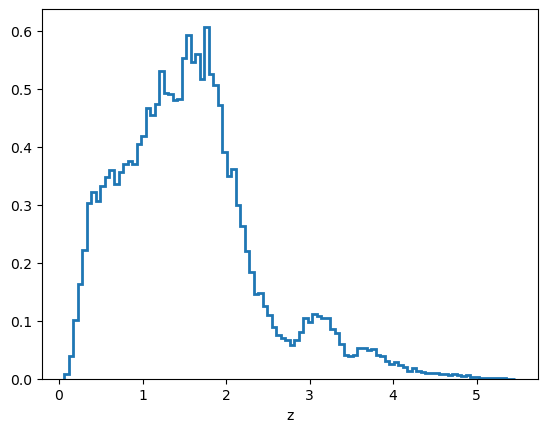

In [8]:
z= np.loadtxt(filename,skiprows=80, usecols=3)
nums, lims, fig  = plt.hist(z,bins=100,density=True,histtype='step',lw=2)
plt.xlabel('z')

- Upsample this distribution in hopefully two ways (but at least one of them), using both rejection sampling and inverse transform.
- Check, at least visually, that the two cloned distribitions are indeed similar to the observed one (for a quantitative check, come back to this point in a few lectures)
- Think about the cosmology of quasars. How do you think they are distributed? Overplot the theorethical distribution to the measured SDSS data. Does that agree with your expectation? 

(Hint: It shouldn't. But why?) 

In [13]:
disth = scipy.stats.rv_histogram((nums,lims))

In [ ]:
# rejection sampling

N = 100000
q = uniform(lims[0], lims[-1], N)
u = uniform(0, nums.max(), N)

mask = (u<=disth.pdf(q))
rs = q[mask]

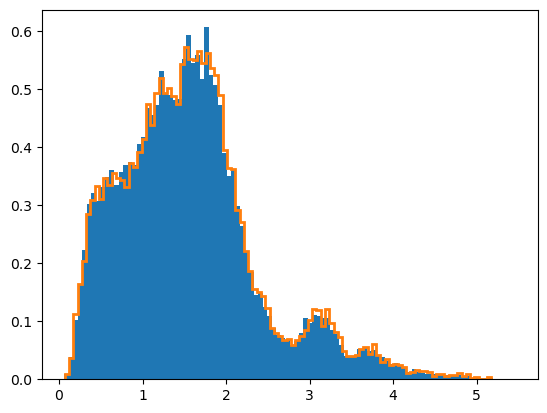

In [25]:
_ = plt.hist(z,bins=100,density=True)
_ = plt.hist(rs,bins=100,density=True,histtype='step',lw=2)

In [ ]:
# inverse transform sampling

U = uniform(0,1, N)
x = disth.ppf(U)

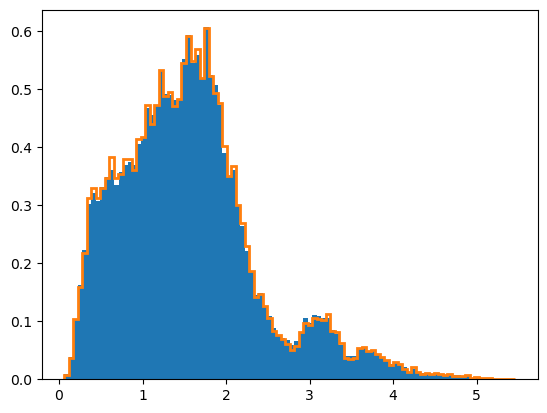

In [27]:
_ = plt.hist(z,bins=100,density=True)
_ = plt.hist(x,bins=100,density=True,histtype='step',lw=2)